In [1]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [2]:
!unzip -q "HAM_CLEAN_SPLIT.zip" -d /content/dataset

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

In [ ]:

CLEAN_ROOT = "/content/dataset/HAM_CLEAN_SPLIT"
TRAIN_DIR  = os.path.join(CLEAN_ROOT, "train")
VAL_DIR    = os.path.join(CLEAN_ROOT, "val")
TEST_DIR   = os.path.join(CLEAN_ROOT, "test")

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)

TRAIN_DIR: /content/dataset/HAM_CLEAN_SPLIT/train
VAL_DIR  : /content/dataset/HAM_CLEAN_SPLIT/val
TEST_DIR : /content/dataset/HAM_CLEAN_SPLIT/test


In [5]:
classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print("\nClasses:", classes)

print("\nCounts:")
for cls in classes:
    n_train = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    n_val   = len(os.listdir(os.path.join(VAL_DIR, cls)))
    n_test  = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"{cls:6s} | Train: {n_train:4d} | Val: {n_val:4d} | Test: {n_test:4d}")


Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Counts:
akiec  | Train:  555 | Val:   49 | Test:   50
bcc    | Train:  350 | Val:   75 | Test:   75
bkl    | Train:  350 | Val:   75 | Test:   75
df     | Train:  504 | Val:   17 | Test:   18
mel    | Train:  350 | Val:   75 | Test:   75
nv     | Train:  350 | Val:   75 | Test:   75
vasc   | Train:  525 | Val:   21 | Test:   22


In [6]:
def count_aug(root):
    c = 0
    for cls in os.listdir(root):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fn in os.listdir(cls_dir):
            if "_aug_" in fn:
                c += 1
    return c

print("\nAugmented in VAL :", count_aug(VAL_DIR))
print("Augmented in TEST:", count_aug(TEST_DIR))


Augmented in VAL : 0
Augmented in TEST: 0


In [7]:
def show_random_images(root_dir, class_name, n=6):
    class_dir = os.path.join(root_dir, class_name)
    files_ = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
    if len(files_) == 0:
        print("No images found:", class_dir)
        return
    sample = random.sample(files_, min(n, len(files_)))

    cols = min(6, len(sample))
    rows = (len(sample) + cols - 1) // cols
    plt.figure(figsize=(cols*3, rows*3))
    for i, f in enumerate(sample):
        img = tf.keras.utils.load_img(os.path.join(class_dir, f), target_size=(224,224))
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"{class_name} ({os.path.basename(root_dir)})", fontsize=14)
    plt.show()

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print("\nClass names:", class_names)

Found 2984 files belonging to 7 classes.
Found 387 files belonging to 7 classes.
Found 390 files belonging to 7 classes.

Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [9]:
mixed_precision.set_global_policy("mixed_float16")

AUTOTUNE = tf.data.AUTOTUNE
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_batch(x, y):
    x = tf.cast(x, tf.float32)
    x = preprocess(x)
    return x, y

train_ds = train_ds.map(preprocess_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_batch,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_batch,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [ ]:
def eca_block(inputs, k_size=3):
  
    channels = inputs.shape[-1]

   
    x = layers.GlobalAveragePooling2D()(inputs)    

    
    x = layers.Reshape((channels, 1))(x)           

    x = layers.Conv1D(
        filters=1,
        kernel_size=k_size,
        padding="same",
        use_bias=False
    )(x)

   
    x = layers.Activation("sigmoid")(x)            

   
    x = layers.Reshape((1, 1, channels))(x)        

    
    return layers.Multiply()([inputs, x])

In [11]:

NUM_CLASSES = len(class_names)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = eca_block(x, k_size=3)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1280, 1)   │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1280, 1)   │          3 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1280, 1)   │          0 │ conv1d[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ activation[0][0]  │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│                     │ 1280)             │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 7)         │      8,967 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,266,954 (8.65 MB)

 Trainable params: 8,970 (35.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_1 = [
    keras.callbacks.ModelCheckpoint("mobilenetv2_eca_best.keras", monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_1)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 96s 645ms/step - accuracy: 0.3781 - loss: 1.6404 - val_accuracy: 0.5065 - val_loss: 1.3466 - learning_rate: 0.0010
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6367 - loss: 1.0360 - val_accuracy: 0.5452 - val_loss: 1.2700 - learning_rate: 0.0010
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6764 - loss: 0.8910 - val_accuracy: 0.5659 - val_loss: 1.1926 - learning_rate: 0.0010
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7210 - loss: 0.7923 - val_accuracy: 0.5995 - val_loss: 1.1607 - learning_rate: 0.0010
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7281 - loss: 0.7488 - val_accuracy: 0.5788 - val_loss: 1.1637 - learning_rate: 0.0010
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7459 - loss: 0.7107 - val_accuracy: 0.6124 - val_loss: 1.1437 - learning_rate: 0.0010
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7668 - loss: 0.6819 - val_a

In [13]:
callbacks = [
    keras.callbacks.ModelCheckpoint("mobilenetv2_eca_best.keras", monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]


In [14]:
model = tf.keras.models.load_model("mobilenetv2_eca_best.keras")

base_model = next(
    l for l in model.layers
    if isinstance(l, tf.keras.Model) and "mobilenetv2" in l.name.lower()
)

base_model.trainable = True
for layer in base_model.layers[:-54]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 128s 772ms/step - accuracy: 0.5827 - loss: 1.3378 - val_accuracy: 0.5943 - val_loss: 1.1526 - learning_rate: 1.0000e-04
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7171 - loss: 0.7071 - val_accuracy: 0.5995 - val_loss: 1.1968 - learning_rate: 1.0000e-04
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7760 - loss: 0.5825 - val_accuracy: 0.6150 - val_loss: 0.9894 - learning_rate: 1.0000e-04
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7980 - loss: 0.5283 - val_accuracy: 0.6563 - val_loss: 0.9639 - learning_rate: 1.0000e-04
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8853 - loss: 0.3143 - val_accuracy: 0.6615 - val_loss: 1.0218 - learning_rate: 1.0000e-04
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9063 - loss: 0.2534 - val_accuracy: 0.6563 - val_loss: 1.0015 - learning_rate: 1.0000e-04
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.94

In [16]:
best_model = keras.models.load_model("mobilenetv2_eca_best.keras")
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\nCLEAN Test accuracy: {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.7031 - loss: 1.0569

CLEAN Test accuracy: 0.7256


Macro F1: 0.7531009156579932
              precision    recall  f1-score   support

       akiec       0.65      0.60      0.62        50
         bcc       0.74      0.85      0.79        75
         bkl       0.71      0.65      0.68        75
          df       0.77      0.94      0.85        18
         mel       0.68      0.65      0.67        75
          nv       0.75      0.71      0.73        75
        vasc       0.91      0.95      0.93        22

    accuracy                           0.73       390
   macro avg       0.74      0.77      0.75       390
weighted avg       0.72      0.73      0.72       390



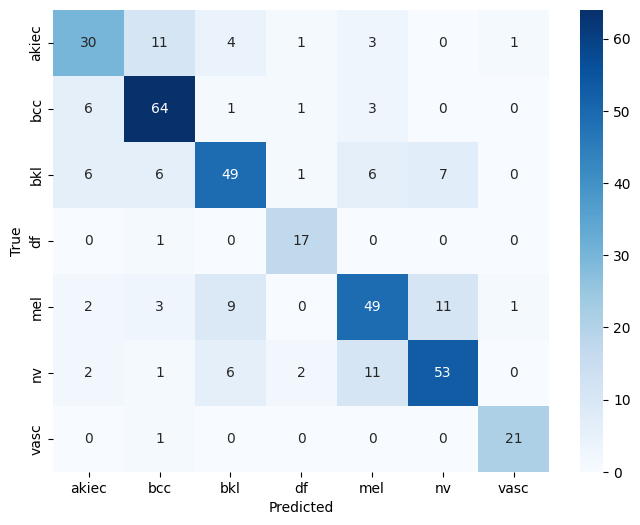

In [17]:
y_true, y_pred = [], []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

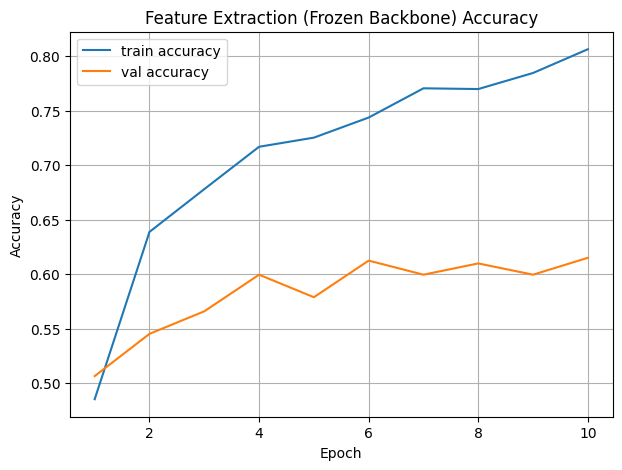

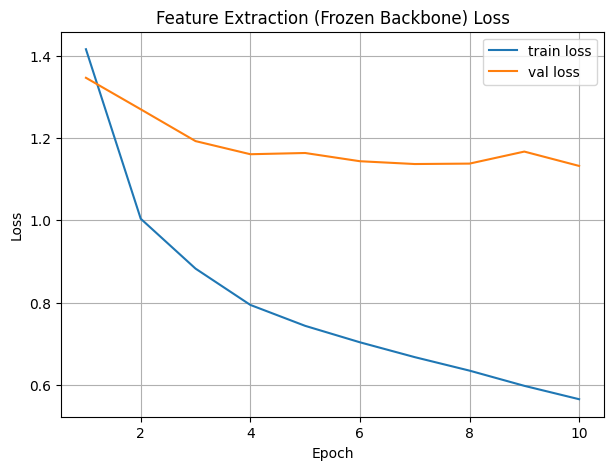

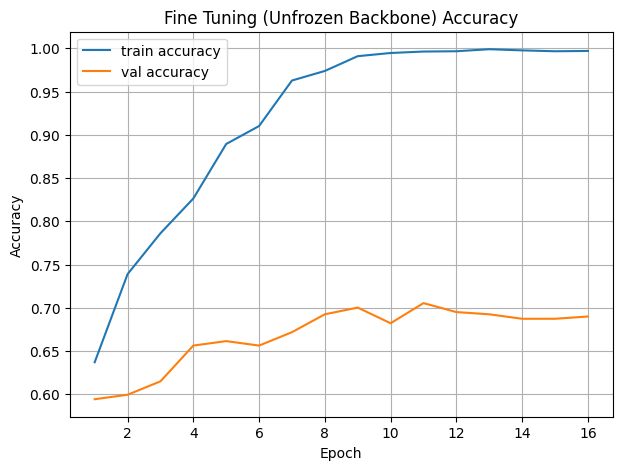

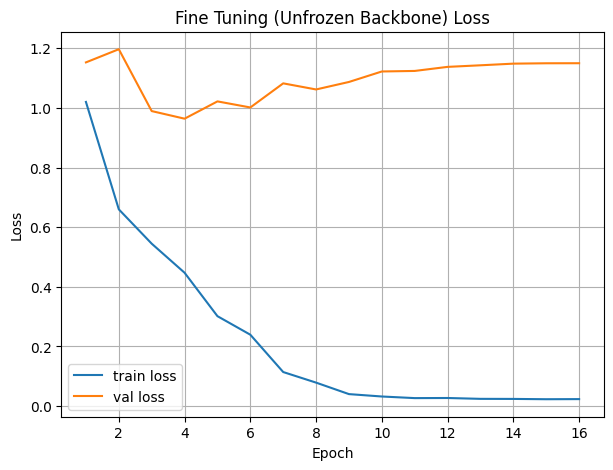

In [ ]:
import matplotlib.pyplot as plt

def plot_history(h, title_prefix=""):
    hist = h.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist["accuracy"], label="train accuracy")
    plt.plot(epochs, hist["val_accuracy"], label="val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist["loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history, "Feature Extraction (Frozen Backbone)")


plot_history(history_fine, "Fine Tuning (Unfrozen Backbone)")

In [ ]:

import numpy as np

cm = confusion_matrix(y_true, y_pred)

specificity = []
for i in range(len(cm)):
    tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
    fp = np.sum(cm[:,i]) - cm[i,i]
    spec = tn / (tn + fp)
    specificity.append(spec)

for cls, spec in zip(class_names, specificity):
    print(f"{cls} Specificity: {spec:.4f}")

akiec Specificity: 0.9529
bcc Specificity: 0.9270
bkl Specificity: 0.9365
df Specificity: 0.9866
mel Specificity: 0.9270
nv Specificity: 0.9429
vasc Specificity: 0.9946


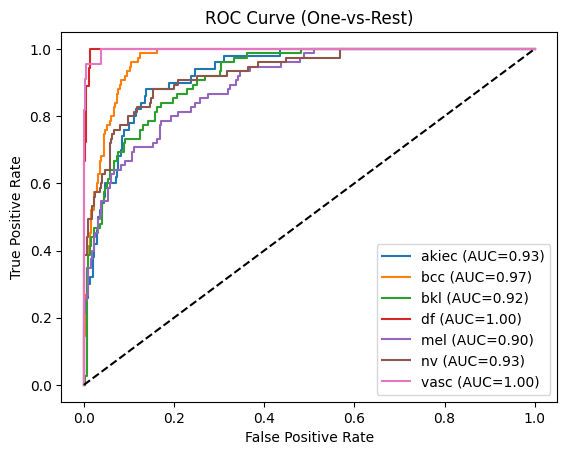

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
y_pred_prob = []

for images, _ in test_ds:
    y_pred_prob.extend(best_model.predict(images, verbose=0))

y_pred_prob = np.array(y_pred_prob)

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [22]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Load full saved model (.keras file)
model = tf.keras.models.load_model("mobilenetv2_eca_best.keras")

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 652ms/step - accuracy: 0.7031 - loss: 1.0569
Test Loss: 1.0061
Test Accuracy: 0.7256


In [23]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# 1) Collect true labels and predicted probabilities
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_prob = np.array(y_prob)

num_classes = y_prob.shape[1]

# 2) Convert y_true to one-hot (required for roc_auc_score)
y_true_onehot = label_binarize(y_true, classes=range(num_classes))

# 3) Compute macro average AUC
macro_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    average="macro",
    multi_class="ovr"
)

print("Macro Average AUC:", macro_auc)

Macro Average AUC: 0.9479615425271077


In [24]:
model.save_weights("eca.weights.h5")